# Analyse exploratoire des donnees du dataset UCI Heart Disease

## Objectifs du notebook

Dans ce notebook nous preparons les données pour la phase de modelisation a travers l'analyse exploratoire et a la preparation des données.

Dans la suite nous:
- chargons les donnees a partir des fichiers locaux UCI ;
- reconstruisons une base fusionnee avec une colonne `source` ;
- verifions la structure reelle des donnees et la qualite des codages ;
- analysons les valeurs manquantes, la cible `num` et les distributions des variables ;
- comparons les hopitaux / sous-bases ;
- preparons les données pour lamodelisation.


In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    import missingno as msno
    HAS_MISSINGNO = True
except ImportError:
    HAS_MISSINGNO = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


## 1. Chargement des donnees a partir des fichiers bruts locaux

Nous chargeons les les données médicales (heart disease dataset de l’UCI), sélectionner les colonnes pertinentes, et les rendre exploitables dans Pandas pour l’analyse dans les bases (`cleveland`, `hungarian`, `switzerland`, `va`).

La documentation UCI indique que chaque fichier brut contient **76 attributs** organises selon le meme schema. Pour notre travail nous nous concentrons sur 14 variables classiques du probleme correspondent aux positions suivantes : `3, 4, 9, 10, 12, 16, 19, 32, 38, 40, 41, 44, 51, 58`.


In [ ]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path.resolve() for path in candidate_roots if (path / "heart_disease").exists()), Path.cwd().resolve())
# Corrected DATA_DIR to point directly to /content where the files are located
DATA_DIR = Path.cwd() # This assumes files are directly in /content

raw_files = {
    "cleveland": "processed.cleveland.data",
    "hungarian": "processed.hungarian.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data",
}

processed_fallback_files = {
    "cleveland": "processed.cleveland.data",
}

attribute_positions = {
    "age": 3,
    "sex": 4,
    "cp": 9,
    "trestbps": 10,
    "chol": 12,
    "fbs": 16,
    "restecg": 19,
    "thalach": 32,
    "exang": 38,
    "oldpeak": 40,
    "slope": 41,
    "ca": 44,
    "thal": 51,
    "num": 58,
}

column_names = list(attribute_positions.keys())
selected_indices = [position - 1 for position in attribute_positions.values()]
missing_markers = {"-9", "-9.", "?"}

print(f"Current working directory: {Path.cwd()}")
print(f"Project root used in this notebook: {PROJECT_ROOT}")
print(f"Data directory detected: {DATA_DIR}")

attribute_map = pd.DataFrame({
    "variable": column_names,
    "uci_position": list(attribute_positions.values()),
    "zero_based_index": selected_indices,
})
display(attribute_map)


Current working directory: /content
Project root used in this notebook: /content
Data directory detected: /content


,variable,uci_position,zero_based_index
0,age,3,2
1,sex,4,3
2,cp,9,8
3,trestbps,10,9
4,chol,12,11
5,fbs,16,15
6,restecg,19,18
7,thalach,32,31
8,exang,38,37
9,oldpeak,40,39


### Les variables retenues

Les 14 variables retenues pour l'analyse sont les suivantes :

- `age` : age du patient
- `sex` : sexe (`1` = homme, `0` = femme)
- `cp` : type de douleur thoracique
- `trestbps` : pression arterielle au repos
- `chol` : cholesterolemie
- `fbs` : glycemie a jeun > 120 mg/dl
- `restecg` : electrocardiogramme au repos
- `thalach` : frequence cardiaque maximale atteinte
- `exang` : angine induite par l'exercice
- `oldpeak` : depression ST induite par l'exercice
- `slope` : pente du segment ST a l'effort
- `ca` : nombre de vaisseaux principaux colores par fluoroscopie
- `thal` : statut thalassemique / type de defaut perfusionnel
- `num` : qui est egalement notre variable cible originale UCI avec classes `0, 1, 2, 3, 4`.


In [ ]:
def parse_raw_source(path, column_names, selected_indices, encoding="latin1"):
    with path.open("r", encoding=encoding, errors="replace") as f:
        lines = [line.strip() for line in f if line.strip()]

    raw_records = []
    for start in range(0, len(lines), 10):
        chunk = lines[start:start + 10]
        if len(chunk) < 10:
            raise ValueError(f"Incomplete block detected in {path.name} starting at line {start}.")

        tokens = []
        for line in chunk:
            tokens.extend(line.split())

        if len(tokens) != 76:
            raise ValueError(
                f"Expected 76 tokens in {path.name} at block starting line {start}, got {len(tokens)}."
            )

        raw_records.append([tokens[index] for index in selected_indices])

    return pd.DataFrame(raw_records, columns=column_names)


### **Netoyage de la base de donnée**

Nous remplacons les marqueurs de valeurs manquantes (-9, ?) par NaN et convertissons toutes les colonnes en numériques (float ou int).

Nous concatenons également tous les fichiers dans un seul DataFrame, en gardeant une colone source pour savoir l'origine de chaque observation.

In [ ]:

def clean_selected_table(df_selected):
    df_clean = df_selected.replace({marker: np.nan for marker in missing_markers}).copy()
    for col in column_names:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
    return df_clean


raw_selected_frames = []
clean_frames = []
loading_status = []

for source, filename in raw_files.items():
    raw_path = DATA_DIR / filename

    try:
        df_selected_raw = parse_raw_source(raw_path, column_names, selected_indices)
        loader_used = "raw"
        file_used = filename
        note = "raw file parsed successfully"
    except Exception as exc:
        fallback_name = processed_fallback_files.get(source)
        if fallback_name is None:
            # If no specific fallback is defined, use the original filename
            # for pd.read_csv. This handles cases where parse_raw_source fails
            # for files other than 'cleveland'.
            fallback_name = filename
            note = f"raw file unusable locally ({type(exc).__name__}), falling back to pd.read_csv with original filename"
        else:
            note = f"raw file unusable locally ({type(exc).__name__})"

        file_used = fallback_name
        loader_used = "processed fallback"
        df_selected_raw = pd.read_csv(DATA_DIR / fallback_name, names=column_names, dtype=str)

    df_selected_raw["source"] = source
    raw_selected_frames.append(df_selected_raw.copy())

    df_source = clean_selected_table(df_selected_raw[column_names])
    df_source["source"] = source
    clean_frames.append(df_source)

    loading_status.append({
        "source": source,
        "file_used": file_used,
        "loader_used": loader_used,
        "rows": len(df_source),
        "note": note,
    })

df_raw_selected = pd.concat(raw_selected_frames, ignore_index=True)
df = pd.concat(clean_frames, ignore_index=True)
df["source"] = df["source"].astype("category")

loading_report = pd.DataFrame(loading_status)
special_missing_counts = (
    df_raw_selected[column_names]
    .isin(missing_markers)
    .sum()
    .rename("n_special_missing")
    .to_frame()
)

display(loading_report)
display(df.head())
print(f"Working dataset shape: {df.shape}")

,source,file_used,loader_used,rows,note
0,cleveland,processed.cleveland.data,processed fallback,303,raw file unusable locally (ValueError)
1,hungarian,processed.hungarian.data,processed fallback,294,"raw file unusable locally (ValueError), fallin..."
2,switzerland,processed.switzerland.data,processed fallback,123,"raw file unusable locally (ValueError), fallin..."
3,va,processed.va.data,processed fallback,200,"raw file unusable locally (ValueError), fallin..."


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,cleveland
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,cleveland
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,cleveland
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,cleveland
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,cleveland


Working dataset shape: (920, 15)


### **Verification robuste de la base de donnée**

In [ ]:

# -----------------------------
# 1. Colonnes
# -----------------------------
columns = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "num"
]

# -----------------------------
# 2. Chemin projet
# -----------------------------
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT # Corrected path to point directly to /content

# -----------------------------
# 3. Fichiers processed
# -----------------------------
files = {
    "cleveland": "processed.cleveland.data",
    "hungarian": "processed.hungarian.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data"
}

# -----------------------------
# 4. Lecture + nettoyage
# -----------------------------
dfs = []

for source, file in files.items():
    path = DATA_DIR / file

    df_temp = pd.read_csv(
        path,
        names=columns,
        na_values=["-", "?", "-9", "-9.0"],  # gestion NA directe, added '-' as per earlier processing
        dtype=str  # important pour éviter erreurs de parsing
    )

    # conversion en numérique
    for col in columns:
        df_temp[col] = pd.to_numeric(df_temp[col], errors="coerce")

    # ajout source
    df_temp["source"] = source

    dfs.append(df_temp)

# -----------------------------
# 5. Fusion
# -----------------------------
df = pd.concat(dfs, ignore_index=True)

# -----------------------------
# 6. Typage
# -----------------------------
df["source"] = df["source"].astype("category")

# -----------------------------
# 7. Vérifications
# -----------------------------
print("Shape :", df.shape)

print("\nObservations par source :")
print(df["source"].value_counts())

print("\nValeurs manquantes :")
display(df.isna().sum())

print("\nAperçu :")
display(df.head())

Shape : (920, 15)

Observations par source :
source
cleveland      303
hungarian      294
va             200
switzerland    123
Name: count, dtype: int64

Valeurs manquantes :


,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalach,55
exang,55
oldpeak,62



Aperçu :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,cleveland
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,cleveland
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,cleveland
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,cleveland
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,cleveland


## 2. Verification de la structure reelle des donnees

Après la fusion des tables nous verifions :
- le nombre d'observations et de variables ;
- les types variables;
- la separation entre variables quantitatives et qualitatives codees numeriquement ;
- la disponibilite effective de la colonne `source`.


In [ ]:
df["source"].value_counts()

,count
source,
cleveland,303
hungarian,294
va,200
switzerland,123


###  Documentation du role de chaque variable et vérification de la structure finale.

In [ ]:
target_col = "num"
source_col = "source"
quantitative_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
binary_features = ["sex", "fbs", "exang"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
all_feature_columns = quantitative_features + categorical_features

variable_roles = pd.DataFrame({
    "variable": column_names + [source_col],
    "pandas_dtype": [str(df[col].dtype) for col in column_names] + [str(df[source_col].dtype)],
    "role": [
        "quantitative" if col in quantitative_features else
        "categorical coded as numeric" if col in categorical_features else
        "target"
        for col in column_names
    ] + ["source identifier"]
})

print(f"Number of rows   : {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
display(pd.DataFrame({"variable": df.columns}))
display(variable_roles)
display(df[source_col].value_counts().sort_index().rename("count").to_frame())

df.info()


Number of rows   : 920
Number of columns: 15


,variable
0,age
1,sex
2,cp
3,trestbps
4,chol
5,fbs
6,restecg
7,thalach
8,exang
9,oldpeak


,variable,pandas_dtype,role
0,age,float64,quantitative
1,sex,float64,categorical coded as numeric
2,cp,float64,categorical coded as numeric
3,trestbps,float64,quantitative
4,chol,float64,quantitative
5,fbs,float64,categorical coded as numeric
6,restecg,float64,categorical coded as numeric
7,thalach,float64,quantitative
8,exang,float64,categorical coded as numeric
9,oldpeak,float64,quantitative


,count
source,
cleveland,303
hungarian,294
switzerland,123
va,200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       920 non-null    float64 
 1   sex       920 non-null    float64 
 2   cp        920 non-null    float64 
 3   trestbps  861 non-null    float64 
 4   chol      890 non-null    float64 
 5   fbs       830 non-null    float64 
 6   restecg   918 non-null    float64 
 7   thalach   865 non-null    float64 
 8   exang     865 non-null    float64 
 9   oldpeak   858 non-null    float64 
 10  slope     611 non-null    float64 
 11  ca        309 non-null    float64 
 12  thal      434 non-null    float64 
 13  num       920 non-null    int64   
 14  source    920 non-null    category
dtypes: category(1), float64(13), int64(1)
memory usage: 101.9 KB


## 3. Nettoyage preliminaire, valeurs manquantes et controle des codages

Dans cette partie nous allons proceder au dignostique des valeurs manquantes, des doublons aisni que toutes les incohérences dans notre base de données. Nous procederons au nettoyage preliminaire. Nous vérifions les fichiers bruts UCI, pour s'assurer que les modalites effectivement observees correspondent bien a la documentation afin d'eviter de traiter comme des categories cliniques valides des codes qui sont en realite des valeurs aberrantes ou des conventions propres a certaines bases.


### ***Vérifications des valeurs manquantes avec codages particuliers***

In [ ]:
missing_markers = ["?", -9, -9.0]

special_missing_counts = (
    df.isin(missing_markers)
    .sum()
    .rename("n_special_missing")
    .to_frame()
)

### ***Verifications et visualisations des valeurs manquantes et des incohérences***

Number of duplicated rows: 2


,n_missing,pct_missing,n_special_missing
ca,611,0.664,0
thal,486,0.528,0
slope,309,0.336,0
fbs,90,0.098,0
oldpeak,62,0.067,0
trestbps,59,0.064,0
thalach,55,0.060,0
exang,55,0.060,0
chol,30,0.033,0
restecg,2,0.002,0


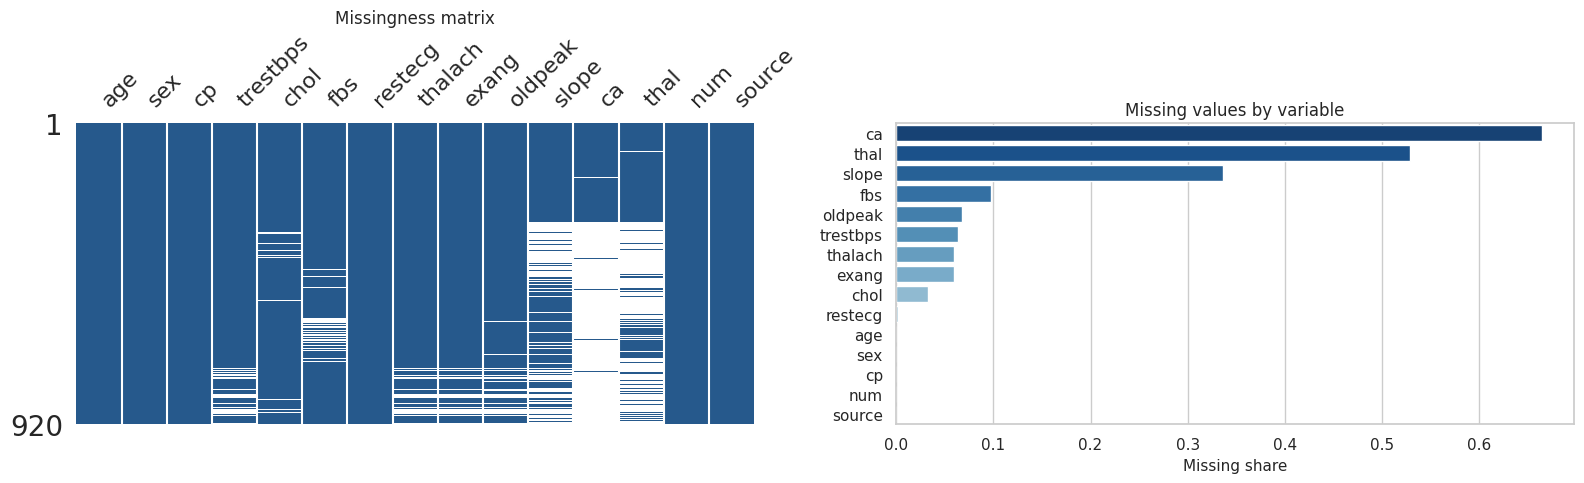

In [ ]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_rows}")

missing_table = df.isna().sum().rename("n_missing").to_frame()
missing_table["pct_missing"] = missing_table["n_missing"] / len(df)
missing_table = missing_table.join(special_missing_counts, how="left").fillna(0)
missing_table["n_special_missing"] = missing_table["n_special_missing"].astype(int)
missing_table = missing_table.sort_values(["pct_missing", "n_missing"], ascending=False)
display(missing_table)

fig, axes = plt.subplots(1, 2 if HAS_MISSINGNO else 1, figsize=(16 if HAS_MISSINGNO else 8, 5))

if HAS_MISSINGNO:
    msno.matrix(df, color=(0.15, 0.35, 0.55), sparkline=False, ax=axes[0])
    axes[0].set_title("Missingness matrix")
    sns.barplot(data=missing_table.reset_index(), x="pct_missing", y="index", ax=axes[1], palette="Blues_r")
    axes[1].set_xlabel("Missing share")
    axes[1].set_ylabel("")
    axes[1].set_title("Missing values by variable")
else:
    ax = axes if not isinstance(axes, np.ndarray) else axes[0]
    sns.barplot(data=missing_table.reset_index(), x="pct_missing", y="index", ax=ax, palette="Blues_r")
    ax.set_xlabel("Missing share")
    ax.set_ylabel("")
    ax.set_title("Missing values by variable")

plt.tight_layout()


Nous observons un trio de variables en tete avc le plus de valeurs maquantes dans notre base de donnée. Il s'agit de la variable `ca` avec 66,4% de valeurs manquantes, la variable `thal` avec 52,8% de valeiurs manquantes et la variable `slop` avec 33,6% de valeurs manquantes. Les autres variables sont sans valeurs manquantes ou ont des valeurs manquantes mais inférieur a 1%.

### ***Audite des variables catégorielles***

Nous vérifions que les valeurs observées dans notre base de donnée correspondent bien aux valeurs documentées par la description du dataset UCI (les « modalités attendues »).

In [ ]:
documented_modalities = {
    "sex": {0, 1},
    "cp": {1, 2, 3, 4},
    "fbs": {0, 1},
    "restecg": {0, 1, 2},
    "exang": {0, 1},
    "slope": {1, 2, 3},
    "ca": {0, 1, 2, 3},
    "thal": {3, 6, 7},
    "num": {0, 1, 2, 3, 4},
}

modality_audit_rows = []
for col, expected_values in documented_modalities.items():
    observed_values = sorted({int(value) if float(value).is_integer() else value for value in df[col].dropna().unique()})
    unexpected_values = [value for value in observed_values if value not in expected_values]
    modality_audit_rows.append({
        "variable": col,
        "expected": sorted(expected_values),
        "observed": observed_values,
        "unexpected": unexpected_values,
    })

modality_audit = pd.DataFrame(modality_audit_rows)
display(modality_audit)

source_modalities = {}
for col in ["slope", "ca", "thal"]:
    source_modalities[col] = pd.crosstab(df[source_col], df[col], dropna=False)

for col, table in source_modalities.items():
    print(f"Observed values by source for {col}")
    display(table)


,variable,expected,observed,unexpected
0,sex,"[0, 1]","[0, 1]",[]
1,cp,"[1, 2, 3, 4]","[1, 2, 3, 4]",[]
2,fbs,"[0, 1]","[0, 1]",[]
3,restecg,"[0, 1, 2]","[0, 1, 2]",[]
4,exang,"[0, 1]","[0, 1]",[]
5,slope,"[1, 2, 3]","[1, 2, 3]",[]
6,ca,"[0, 1, 2, 3]","[0, 1, 2, 3]",[]
7,thal,"[3, 6, 7]","[3, 6, 7]",[]
8,num,"[0, 1, 2, 3, 4]","[0, 1, 2, 3, 4]",[]


Observed values by source for slope


slope,1.000,2.000,3.000
source,,,
cleveland,142,140,21
hungarian,12,91,1
switzerland,33,61,12
va,16,53,29


Observed values by source for ca


ca,0.000,1.000,2.000,3.000
source,,,,
cleveland,176,65,38,20
hungarian,3,0,0,0
switzerland,0,2,3,0
va,2,0,0,0


Observed values by source for thal


thal,3.000,6.000,7.000
source,,,
cleveland,166,18,117
hungarian,7,10,11
switzerland,19,10,42
va,4,8,22


On constate que toutes les valeurs observées correspondent aux modalités documentées. Cependant l'audit par source montre montre que certaines bases (Hungarian, Switzerland, VA) sont moins complètes que Cleveland, ce qui est cohérent avec ce que nous savons du dataset UCI.

## 4. Analyse de la variable cible

La variable `num` est notre variable cible. L'usage des fichiers bruts permet de conserver une cible multiclasse plus fidele au probleme initial, notamment pour la base hongroise, alors que certaines versions `processed` simplifient deja ce codage.


In [ ]:
!pip install loguru
from loguru import logger
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for col in cat_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col_name in cat_cols:
    logger.info(f"{col_name} ==============\n {df[col_name].value_counts(dropna=False)}\n")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.8 MB/s eta 0:00:00


2026-05-07 20:05:27.609 | INFO     | __main__:<cell line: 0>:8 - sex ==============
 sex
1.000    726
0.000    194
Name: count, dtype: int64

2026-05-07 20:05:27.613 | INFO     | __main__:<cell line: 0>:8 - cp ==============
 cp
4.000    496
3.000    204
2.000    174
1.000     46
Name: count, dtype: int64

2026-05-07 20:05:27.615 | INFO     | __main__:<cell line: 0>:8 - fbs ==============
 fbs
0.000    692
1.000    138
NaN       90
Name: count, dtype: int64

2026-05-07 20:05:27.617 | INFO     | __main__:<cell line: 0>:8 - restecg ==============
 restecg
0.000    551
2.000    188
1.000    179
NaN        2
Name: count, dtype: int64

2026-05-07 20:05:27.619 | INFO     | __main__:<cell line: 0>:8 - exang ==============
 exang
0.000    528
1.000    337
NaN       55
Name: count, dtype: int64

2026-05-07 20:05:27.621 | INFO     | __main__:<cell line: 0>:8 - slope ==============
 slope
2.000    345
NaN      309
1.000    203
3.000     63
Name: count, dtype: int64

2026-05-07 20:05:27.623 | INFO

### ***Visualisation de la variable cible***

Nous vérifions la distribution de la variable cible. Nous utilisons deux approche pour la variable cible. Une approche multiuclasse et une approche binaire.

,count,proportion
num,,
0,411,0.447
1,265,0.288
2,109,0.118
3,107,0.116
4,28,0.030


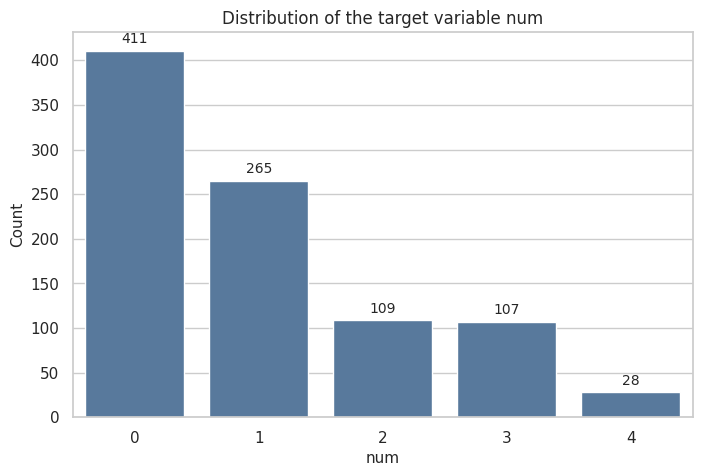

Preview of a future binary target (0 vs 1-4):


,count,proportion
num,,
0,411,0.447
1,509,0.553


In [ ]:
target_summary = df[target_col].value_counts().sort_index().rename("count").to_frame()
target_summary["proportion"] = target_summary["count"] / len(df)
display(target_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=target_summary.index.astype(str), y=target_summary["count"], color="#4C78A8", ax=ax)

for i, value in enumerate(target_summary["count"]):
    ax.text(i, value + 5, str(int(value)), ha="center", va="bottom", fontsize=10)

ax.set_xlabel("num")
ax.set_ylabel("Count")
ax.set_title("Distribution of the target variable num")
plt.show()

binary_preview = df[target_col].gt(0).map({False: 0, True: 1}).value_counts().sort_index().rename("count").to_frame()
binary_preview["proportion"] = binary_preview["count"] / len(df)
print("Preview of a future binary target (0 vs 1-4):")
display(binary_preview)


,proportion,percentage
num,,
0,0.447,44.674
1,0.288,28.804
2,0.118,11.848
3,0.116,11.630
4,0.030,3.043


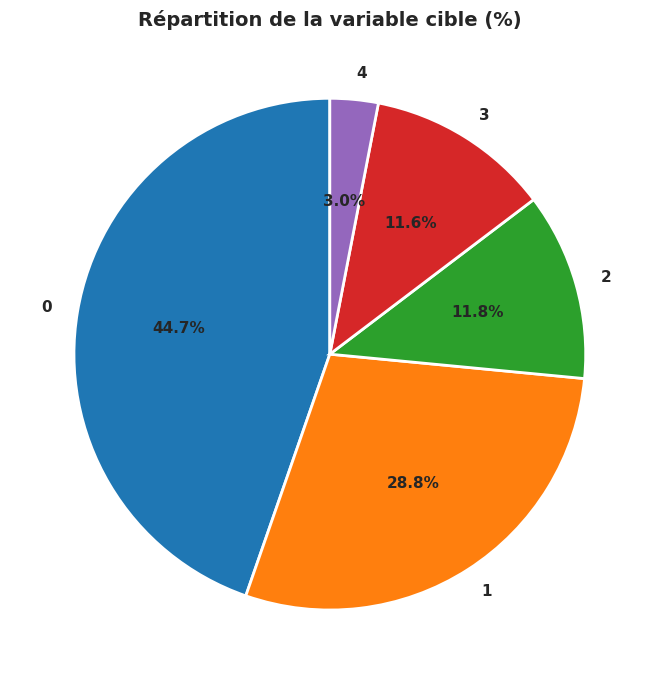

In [ ]:

sns.set_style("white")  # fond propre
# Calcul des pourcentages
target_percent = (
    df[target_col]
    .value_counts(normalize=True)  # proportions
    .sort_index()
    .rename("proportion")
    .to_frame()
)
# Conversion en pourcentage
target_percent["percentage"] = target_percent["proportion"] * 100

# Affichage du tableau
display(target_percent)
# Palette moderne (très propre visuellement)
colors = sns.color_palette("tab10", len(target_percent))
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    target_percent["percentage"],
    labels=target_percent.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={'fontsize': 11, 'weight': 'bold'}
)

ax.set_title("Répartition de la variable cible (%)", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()


Selon l'approche multiclasse notre variable cible les classes `1`, `2` et `3` disposent d'effectifs non negligeables, alors que la classe `4` reste clairement minoritaire.  Une classification multiclasse demandera donc une evaluation soigneuse et une attention particuliere au desequilibre des classes.

En parallele, il reste pertinent de preparer une version binaire `0` vs `1-4` afin de comparer les deux formulations du probleme dans la suite du projet.

## 5. Analyse univariee

Cette partie decrit la distribution de chaque variable de facon individuelle. Elle sert a repérer les asymetries, les valeurs extremes, les categories rares et les distributions tres lacunaires.


,count,mean,std,min,25%,50%,75%,max
age,920.000,53.511,9.425,28.000,47.000,54.000,60.000,77.000
trestbps,861.000,132.132,19.066,0.000,120.000,130.000,140.000,200.000
chol,890.000,199.130,110.781,0.000,175.000,223.000,268.000,603.000
thalach,865.000,137.546,25.926,60.000,120.000,140.000,157.000,202.000
oldpeak,858.000,0.879,1.091,-2.600,0.000,0.500,1.500,6.200


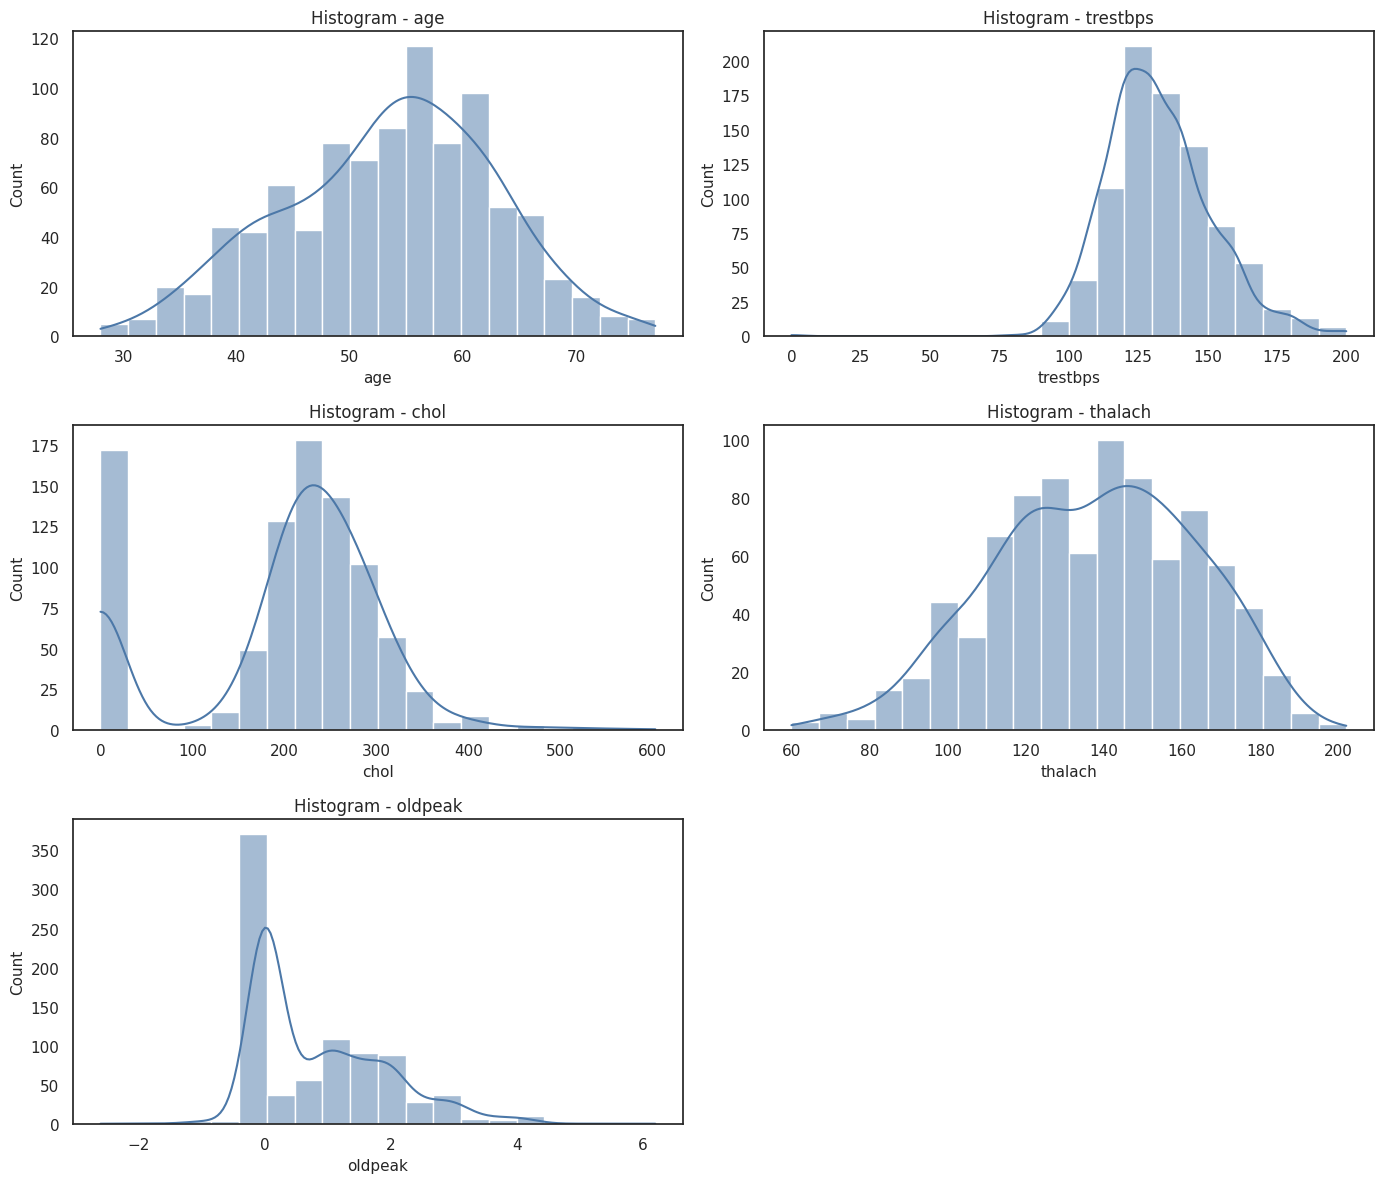

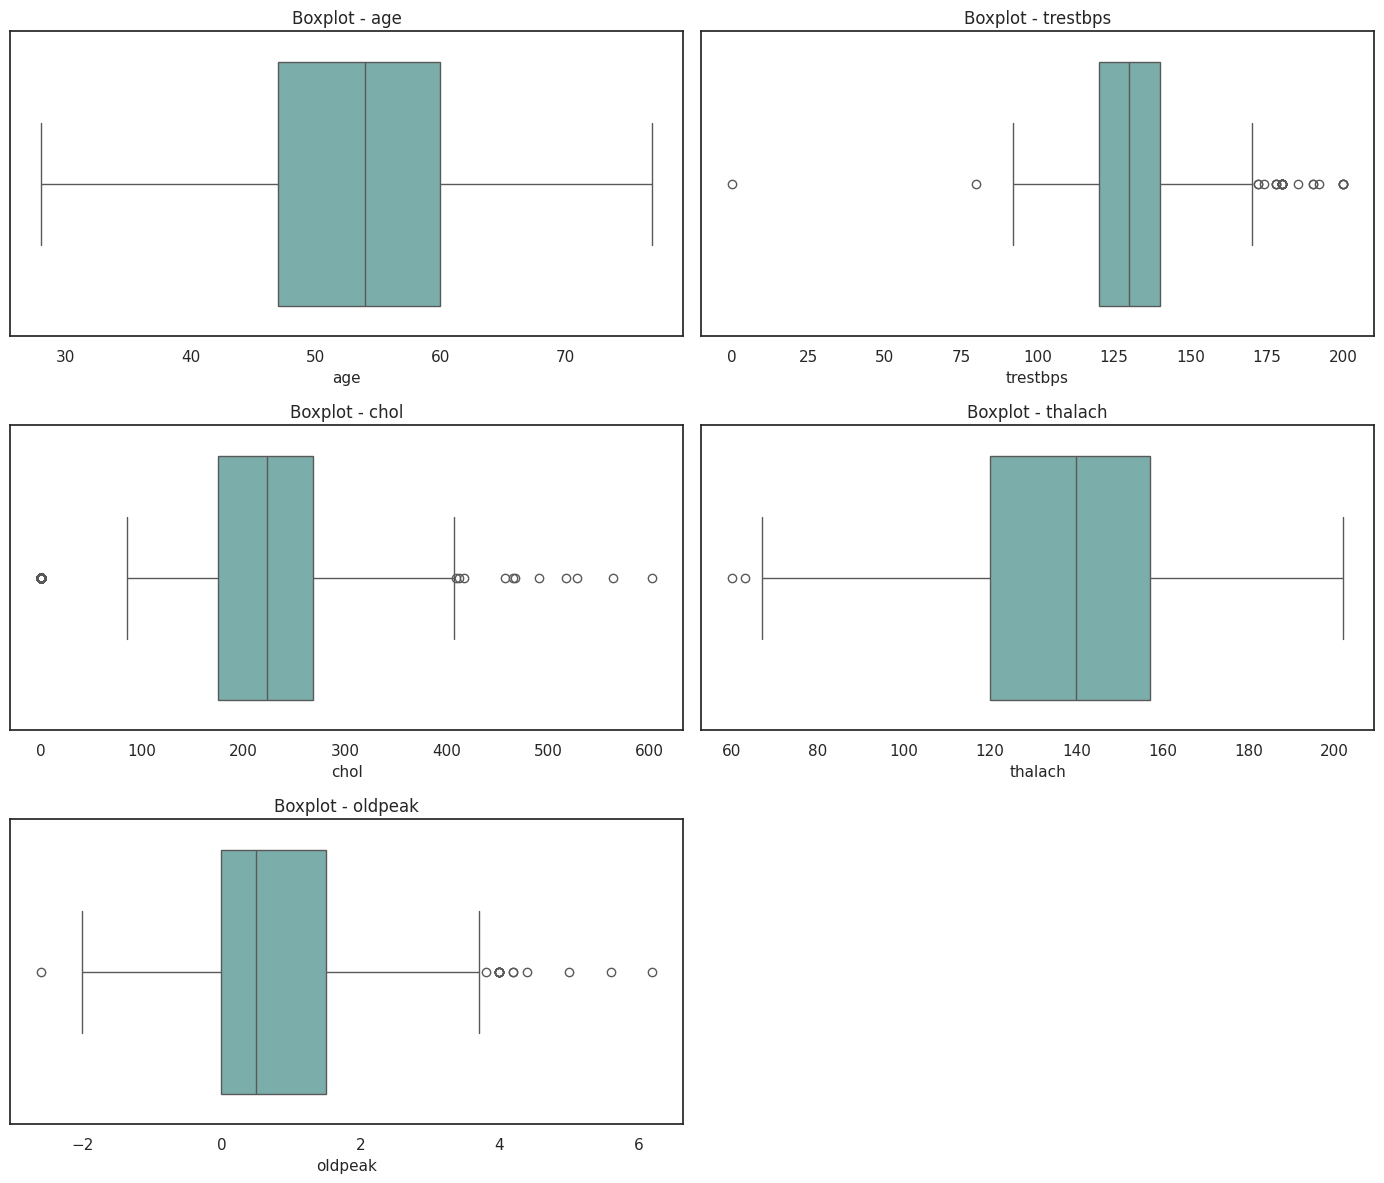

In [ ]:
display(df[quantitative_features].describe().T)

ncols = 2
nrows = int(np.ceil(len(quantitative_features) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, quantitative_features):
    sns.histplot(df[col], kde=True, bins=20, color="#4C78A8", ax=ax)
    ax.set_title(f"Histogram - {col}")
    ax.set_xlabel(col)

for ax in axes[len(quantitative_features):]:
    ax.set_visible(False)

plt.tight_layout()

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, quantitative_features):
    sns.boxplot(x=df[col], color="#72B7B2", ax=ax)
    ax.set_title(f"Boxplot - {col}")
    ax.set_xlabel(col)

for ax in axes[len(quantitative_features):]:
    ax.set_visible(False)

plt.tight_layout()


In [ ]:
# Statistiques pour les quantitatives
stats_enrichies = df[quantitative_features].agg([
    "mean", "median", "std", "skew",
    lambda x: x.kurtosis()
]).rename(index={"<lambda_0>": "kurtosis"})

# Skewness > 1 = asymétrie forte → signal pour transformation future
print("=== Asymétrie et aplatissement ===")
display(stats_enrichies.T.round(3))

# Vérification des zéros biologiquement impossibles
print("\n=== Zéros suspects (trestbps, chol) ===")
for col in ["trestbps", "chol"]:
    n_zeros = (df[col] == 0).sum()
    print(f"{col} : {n_zeros} valeurs à 0")

=== Asymétrie et aplatissement ===


,mean,median,std,skew,<lambda>
age,53.511,54.000,9.425,-0.196,-0.383
trestbps,132.132,130.000,19.066,0.213,2.959
chol,199.130,223.000,110.781,-0.614,0.062
thalach,137.546,140.000,25.926,-0.211,-0.480
oldpeak,0.879,0.500,1.091,1.041,1.127



=== Zéros suspects (trestbps, chol) ===
trestbps : 1 valeurs à 0
chol : 172 valeurs à 0


### ***Exploration des variables catégorielles***

,sex,count,proportion
0,0.0,194,0.211
1,1.0,726,0.789


,cp,count,proportion
0,1.0,46,0.050
1,2.0,174,0.189
2,3.0,204,0.222
3,4.0,496,0.539


,fbs,count,proportion
0,0.0,692,0.752
1,1.0,138,0.150
2,Missing,90,0.098


,restecg,count,proportion
0,0.0,551,0.599
1,1.0,179,0.195
2,2.0,188,0.204
3,Missing,2,0.002


,exang,count,proportion
0,0.0,528,0.574
1,1.0,337,0.366
2,Missing,55,0.060


,slope,count,proportion
0,1.0,203,0.221
1,2.0,345,0.375
2,3.0,63,0.068
3,Missing,309,0.336


,ca,count,proportion
0,0.0,181,0.197
1,1.0,67,0.073
2,2.0,41,0.045
3,3.0,20,0.022
4,Missing,611,0.664


,thal,count,proportion
0,3.0,196,0.213
1,6.0,46,0.050
2,7.0,192,0.209
3,Missing,486,0.528


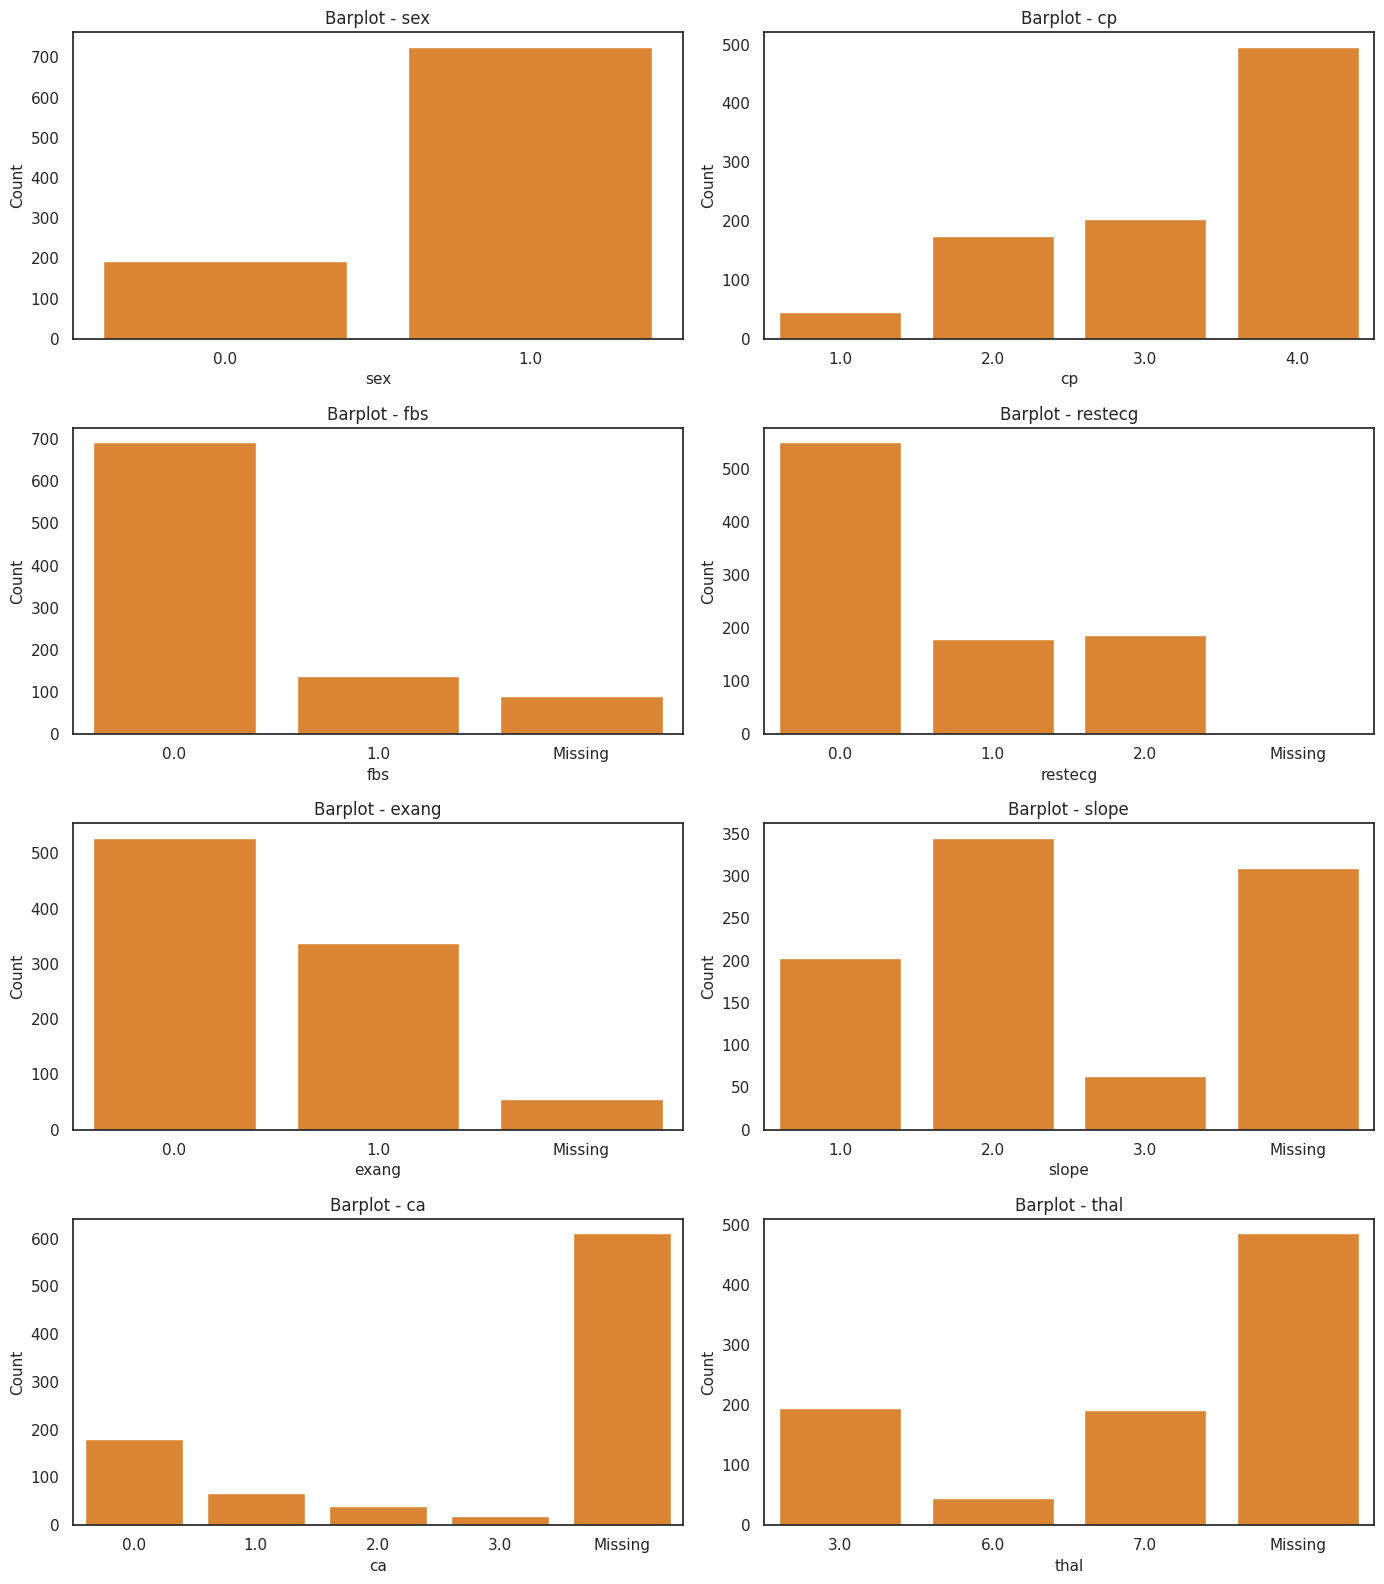

In [ ]:
def prepare_categorical_plot_data(series):
    # Conversion robuste
    formatted = series.astype("Float64")

    # Transformer en string + gérer TOUS les NA
    formatted = formatted.astype(str)
    formatted = formatted.replace({"<NA>": "Missing", "nan": "Missing"})

    # Garder seulement les vraies valeurs
    observed_labels = [
        label for label in formatted.unique().tolist()
        if label != "Missing"
    ]

    # Tri sécurisé
    def safe_int(x):
        try:
            return int(float(x))
        except:
            return float("inf")

    ordered_labels = sorted(observed_labels, key=safe_int)

    # Ajouter Missing à la fin
    if "Missing" in formatted.values:
        ordered_labels.append("Missing")

    return formatted, ordered_labels

categorical_summaries = {}
for col in categorical_features:
    formatted, order = prepare_categorical_plot_data(df[col])
    summary = formatted.value_counts(dropna=False).reindex(order).rename_axis(col).reset_index(name="count")
    summary["proportion"] = summary["count"] / len(df)
    categorical_summaries[col] = summary
    display(summary)

ncols = 2
nrows = int(np.ceil(len(categorical_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, categorical_features):
    formatted, order = prepare_categorical_plot_data(df[col])
    sns.countplot(x=formatted, order=order, color="#F58518", ax=ax)
    ax.set_title(f"Barplot - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()


### ***Mesure de la force d'association entre chaque variable catégorielle et la variable cible***

In [ ]:
from scipy.stats import chi2_contingency

print("=== Test du Chi² : association avec num ===\n")

for col in categorical_features:
    ct = pd.crosstab(df[col].dropna(), df.loc[df[col].notna(), "num"])
    chi2, p, dof, _ = chi2_contingency(ct)

    # V de Cramer pour la taille d'effet
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    signal = "fort" if cramers_v > 0.3 else "modéré" if cramers_v > 0.1 else "faible"
    print(f"{col:12s} → p={p:.4f}  V de Cramér={cramers_v:.3f}  {signal}")

=== Test du Chi² : association avec num ===

sex          → p=0.0000  V de Cramér=0.309  fort
cp           → p=0.0000  V de Cramér=0.314  fort
fbs          → p=0.0001  V de Cramér=0.172  modéré
restecg      → p=0.0000  V de Cramér=0.146  modéré
exang        → p=0.0000  V de Cramér=0.468  fort
slope        → p=0.0000  V de Cramér=0.292  modéré
ca           → p=0.0000  V de Cramér=0.348  fort
thal         → p=0.0000  V de Cramér=0.363  fort


L’analyse du Chi² et du V de Cramér montre que les variables exang, thal, ca, cp et sex sont fortement associées à la variable cible num. Les variables fbs, restecg et slope présentent une association modérée. Dans tous les cas, les p-values sont inférieures à 0.001, ce qui confirme que ces associations sont statistiquement significatives. Ainsi, les variables fortement associées apparaissent comme des prédicteurs particulièrement pertinents pour la classification, tandis que les variables modérées apportent une information complémentaire mais moins discriminante.

## 6. Analyse bivariee avec la cible

Dans cette partie nous cherchons a mettre en relation les covariables et la cible `num`, afin d'avoir une idée de relation entre la cible et les autres variables. L'objectif est d'identifier les signaux cliniquement plausibles et les variables qui pourraient etre discriminantes dans une future modelisation.


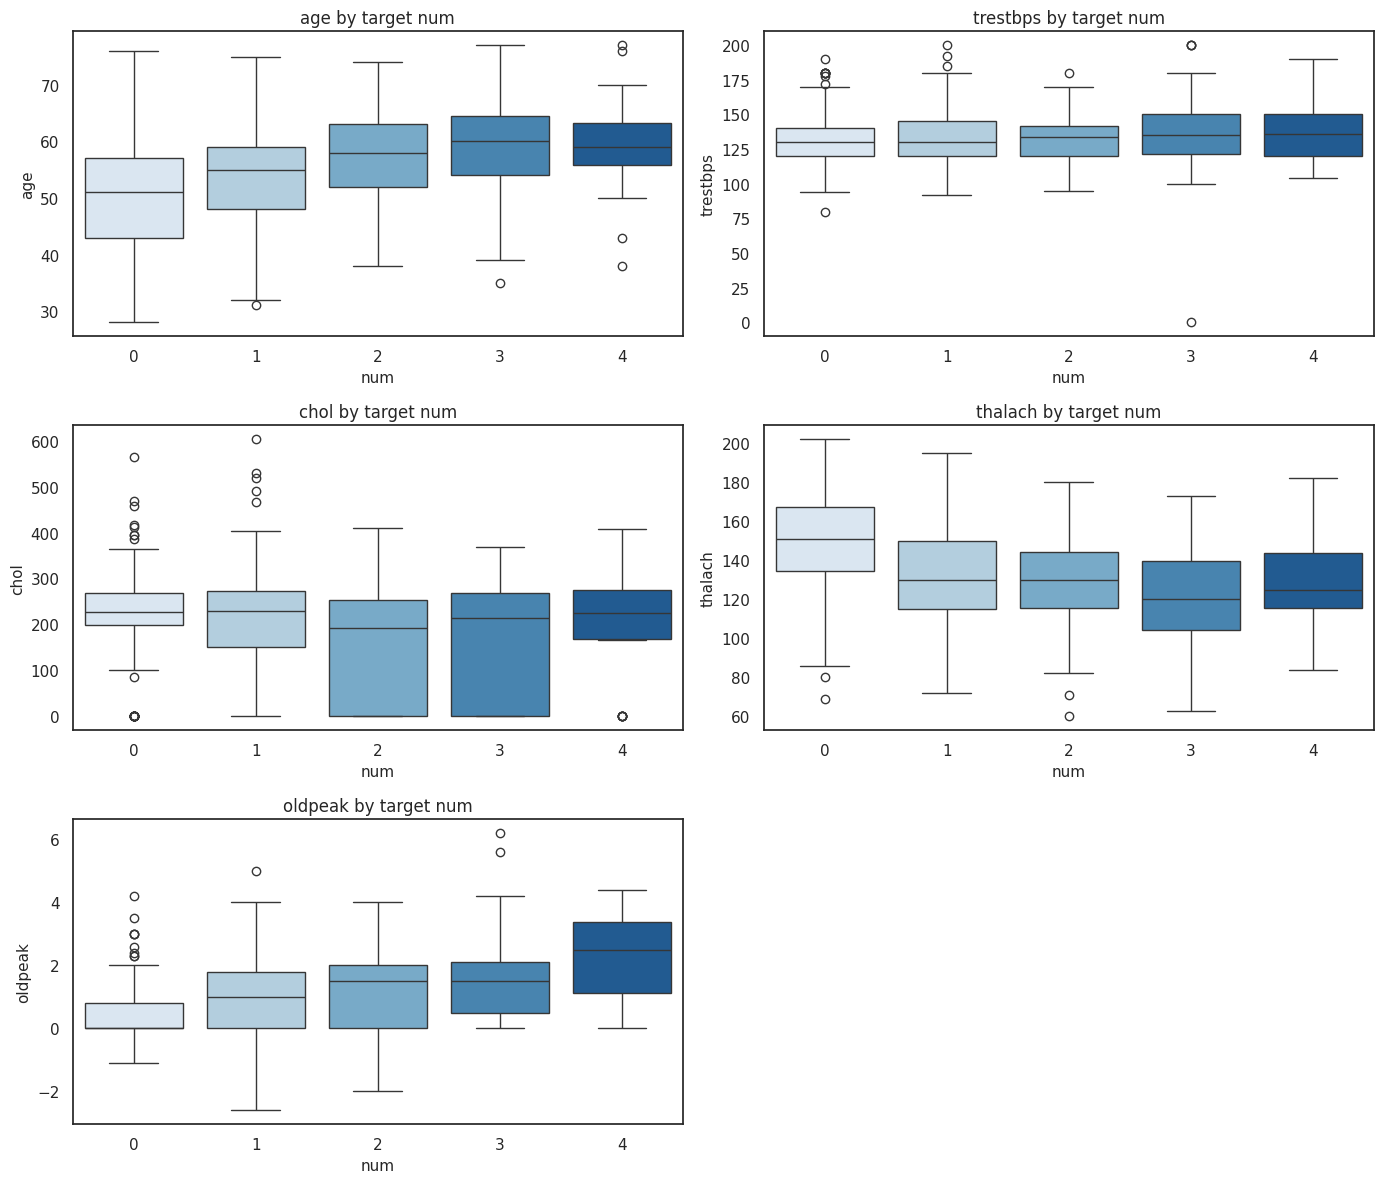

In [ ]:
ncols = 2
nrows = int(np.ceil(len(quantitative_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, quantitative_features):
    sns.boxplot(data=df, x=target_col, y=col, palette="Blues", ax=ax)
    ax.set_title(f"{col} by target num")
    ax.set_xlabel("num")
    ax.set_ylabel(col)

for ax in axes[len(quantitative_features):]:
    ax.set_visible(False)

plt.tight_layout()


## Interprétation des boxplots

- **Age**

La médiane progresse de ~51 ans en classe 0 à ~58 ans en classe 3, puis redescend légèrement en classe 4. On observe donc une tendance croissante mais non parfaitement monotone. Les intervalles interquartiles (IQR) se chevauchent fortement, ce qui limite le pouvoir discriminant de l’âge pris isolément. Il reste néanmoins utile en combinaison avec d’autres variables.

 - **Trestbps (pression artérielle au repos)**

Les distributions sont très proches entre les classes, avec une légère hausse en classe 4. La présence d’un outlier à zéro en classe 2 est biologiquement impossible et confirme l’existence de valeurs manquantes mal codées. Globalement, le signal est faible et cette variable seule n’apporte pas une forte capacité de discrimination.

- **Chol (cholestérol sérique)**

Les médianes sont toutes centrées autour de 220 mg/dl, sans différence notable entre les classes. Paradoxalement, les outliers sont plus fréquents en classe 0.

- **Thalach (fréquence cardiaque maximale atteinte)**

C’est l’un des signaux les plus clairs. La médiane est d’environ 150 bpm en classe 0 et chute progressivement jusqu’à ~125 bpm en classes 3–4. La tendance décroissante est nette et les boîtes se chevauchent moins que pour les autres variables.

- **Oldpeak (dépression ST induite par l’effort)**

On observe une tendance monotone croissante très lisible : médiane proche de 0 en classe 0, puis ~2.5 en classe 4. De plus, la variabilité augmente avec la sévérité, ce qui reflète une hétérogénéité clinique plus marquée chez les patients graves.



### Analyse croisée des variables catégorielles

Feature: sex


num,0,1,2,3,4
sex,,,,,
0.0,144,30,10,8,2
1.0,267,235,99,99,26


num,0,1,2,3,4
sex,,,,,
0.0,0.742,0.155,0.052,0.041,0.010
1.0,0.368,0.324,0.136,0.136,0.036


Feature: cp


num,0,1,2,3,4
cp,,,,,
1.0,26,12,4,3,1
2.0,150,19,2,3,0
3.0,131,37,14,18,4
4.0,104,197,89,83,23


...

num,0,1,2,3,4
ca,,,,,
0.0,133,28,9,8,3
1.0,21,20,14,9,3
2.0,8,7,9,15,2
3.0,3,3,4,5,5
Missing,246,207,73,70,15


num,0,1,2,3,4
ca,,,,,
0.0,0.735,0.155,0.050,0.044,0.017
1.0,0.313,0.299,0.209,0.134,0.045
2.0,0.195,0.171,0.220,0.366,0.049
3.0,0.150,0.150,0.200,0.250,0.250
Missing,0.403,0.339,0.119,0.115,0.025


Feature: thal


num,0,1,2,3,4
thal,,,,,
3.0,138,30,14,12,2
6.0,11,13,12,7,3
7.0,38,63,37,43,11
Missing,224,159,46,45,12


num,0,1,2,3,4
thal,,,,,
3.0,0.704,0.153,0.071,0.061,0.010
6.0,0.239,0.283,0.261,0.152,0.065
7.0,0.198,0.328,0.193,0.224,0.057
Missing,0.461,0.327,0.095,0.093,0.025


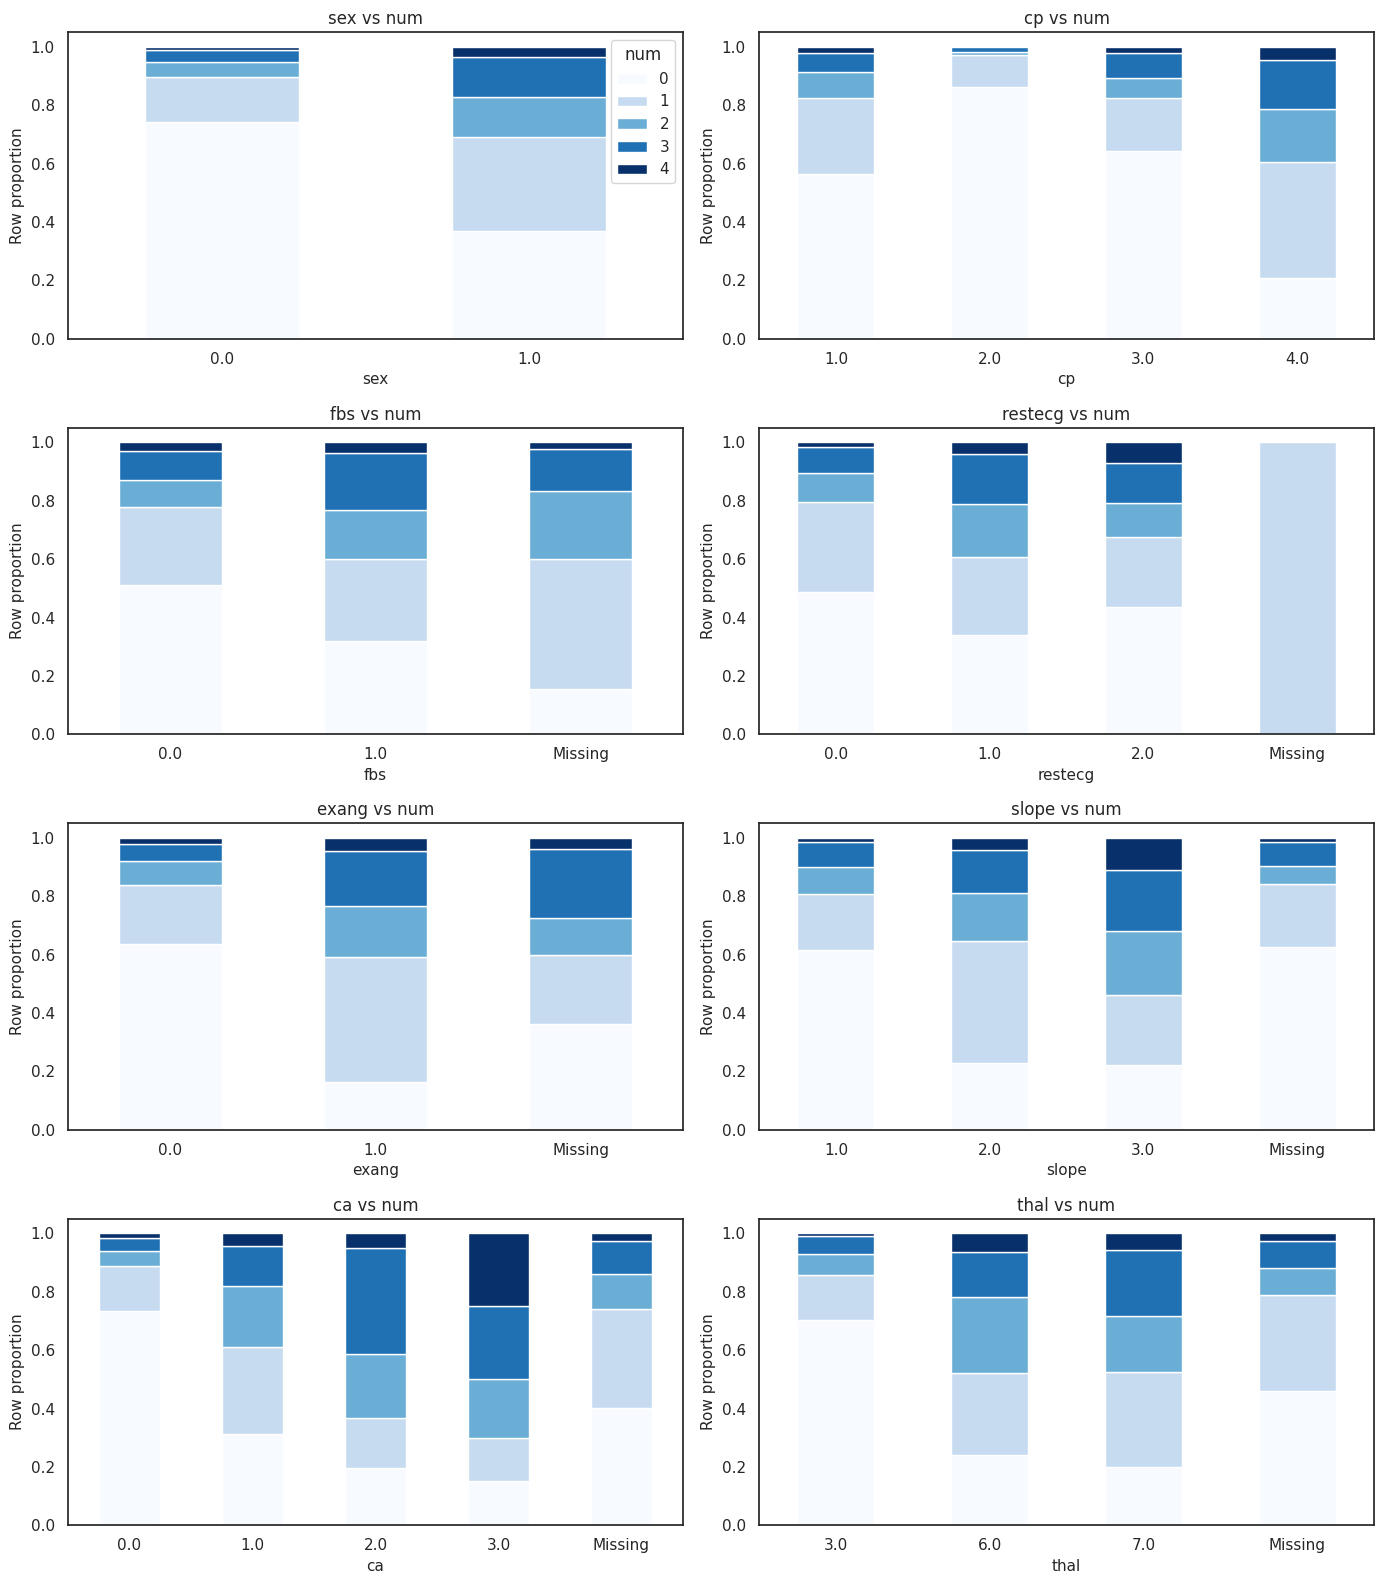

In [ ]:
for col in categorical_features:
    formatted, order = prepare_categorical_plot_data(df[col])
    counts = pd.crosstab(formatted, df[target_col]).reindex(order)
    proportions = pd.crosstab(formatted, df[target_col], normalize="index").reindex(order)
    print(f"Feature: {col}")
    display(counts)
    display(proportions.round(3))

ncols = 2
nrows = int(np.ceil(len(categorical_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)
first_col = categorical_features[0]

for ax, col in zip(axes, categorical_features):
    formatted, order = prepare_categorical_plot_data(df[col])
    proportions = pd.crosstab(formatted, df[target_col], normalize="index").reindex(order)
    proportions.plot(kind="bar", stacked=True, colormap="Blues", ax=ax, legend=(col == first_col))
    ax.set_title(f"{col} vs num")
    ax.set_xlabel(col)
    ax.set_ylabel("Row proportion")
    ax.tick_params(axis="x", rotation=0)
    if col == first_col:
        ax.legend(title="num")

for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()


## Interprétation des variables catégorielles

- **Sexe**  

Les femmes (sex=0) sont majoritairement en classe 0 (≈74 % sans maladie), tandis que les hommes (sex=1) présentent une distribution plus équilibrée et une proportion nettement plus élevée de classes 1–3.
Le sexe est fortement associé à la présence de maladie cardiaque, les hommes étant plus touchés.

- **Type de douleur thoracique (cp)**

**cp=2 (angine atypique)**  
La très grande majorité des patients avec ce profil (≈86 %) sont en classe 0, c’est-à-dire sans maladie cardiaque détectée. Cela suggère que ce type de douleur est souvent bénin et peu associé à une atteinte coronarienne sévère.

**cp=4 (douleur typique d’angine)**  
Ici, la proportion de patients en classe 0 chute fortement (≈21 %), tandis que près de 40 % se retrouvent en classe 1 et une part importante dans les classes plus sévères.


- **Glycémie à jeun (fbs)**

Les patients avec fbs=1 présentent une proportion plus élevée de classes 2–3 (~17–20 %), mais la différence reste modérée.

- **Électrocardiogramme au repos (restecg)**

Les proportions sont relativement proches entre classes, avec quelques variations.


- **Angine induite par l’effort (exang)**

**exang = 0 (pas d’angine induite par l’effort)**
Environ 64 % des patients sont en classe 0, c’est-à-dire sans maladie cardiaque.

**exang = 1 (présence d’angine induite par l’effort)**
La proportion de patients en classe 0 chute à seulement 16 %. À l’inverse, plus de 40 % des patients se retrouvent en classe 1, et une part importante dans les classes plus sévères.

- **Pente du segment ST (slope)**

**slope = 1 (pente ascendante)**  
Environ 62 % des patients avec cette modalité sont en classe 0 (sans maladie).

**slope = 2 (pente plate)**  
La proportion de patients en classe 0 tombe à 23 %, tandis que 42 % se retrouvent en classe 1.

**slope = 3 (pente descendante)**  
Les proportions sont plus équilibrées entre les classes, sans tendance aussi nette que pour slope=1 ou slope=2.

- **Nombre de vaisseaux colorés (ca)**

**ca = 0 (aucun vaisseau coloré)**  
Environ 73 % des patients avec cette modalité sont en classe 0, c’est-à-dire sans maladie cardiaque. Cela montre que l’absence de vaisseaux coronaires obstrués est fortement associée à un état sain.

**ca = 2 ou 3 (deux ou trois vaisseaux colorés)**  
Les proportions de patients dans les classes 2 à 4 (maladie plus sévère) augmentent nettement. Autrement dit, plus le nombre de vaisseaux coronaires atteints est élevé, plus la probabilité d’une maladie cardiaque sévère est grande.

- **Test thalassemia (thal)**

**thal = 3 (valeur normale)**  
Environ 70 % des patients avec cette modalité sont en classe 0, c’est-à-dire sans maladie cardiaque. Cela montre que ce profil est fortement associé à un état sain.

**thal = 7 (valeur pathologique, défaut fixe)**  
La proportion de patients en classe 0 chute à seulement 20 %. À l’inverse, une grande partie des patients se retrouve en classes 1 à 3, ce qui indique une forte corrélation avec la présence de maladie cardiaque.

**thal = 6 (défaut réversible)**
Les proportions sont intermédiaires, avec une distribution plus équilibrée entre les classes, mais toujours moins protectrice que thal=3.

## 7. Correlations et redondances

Avant la modelisation, il est utile de verifier si certaines variables quantitatives sont tres redondantes entre elles. Une correlation elevée pourrait justifier un traitement particulier selon le type de modele retenu plus tard.


In [ ]:
print("\nValeurs manquantes :")
display(df.isna().sum())


Valeurs manquantes :


,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalach,55
exang,55
oldpeak,62


### ***Visualisation de la corrélation des variables quantitatives***

,age,trestbps,chol,thalach,oldpeak
age,1.000,0.244,-0.086,-0.366,0.258
trestbps,0.244,1.000,0.093,-0.105,0.162
chol,-0.086,0.093,1.000,0.236,0.048
thalach,-0.366,-0.105,0.236,1.000,-0.151
oldpeak,0.258,0.162,0.048,-0.151,1.000


No pair of quantitative variables exceeds an absolute correlation of 0.60.


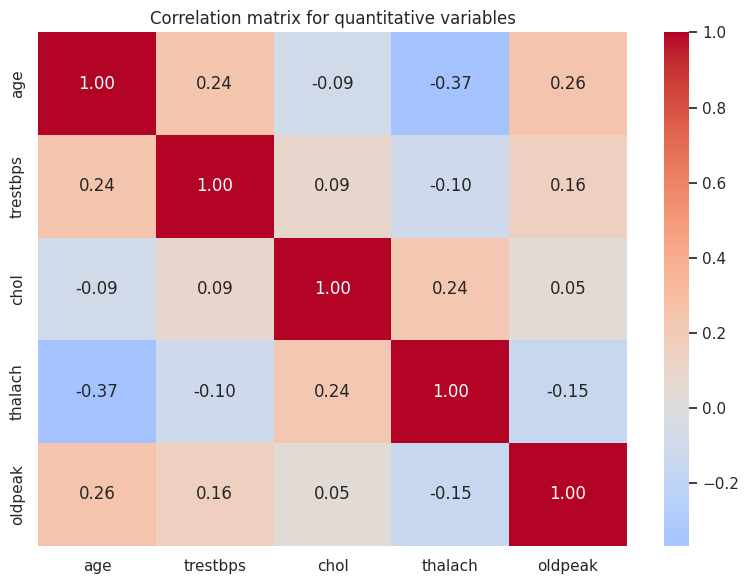

In [ ]:
corr = df[quantitative_features].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation matrix for quantitative variables")
plt.tight_layout()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()

strong_pairs = high_corr_pairs.query("abs_correlation >= 0.60").sort_values("abs_correlation", ascending=False)
if strong_pairs.empty:
    print("No pair of quantitative variables exceeds an absolute correlation of 0.60.")
else:
    display(strong_pairs)


La matrice de corrélation des variables quantitatives montre que les relations entre elles sont globalement faibles à modérées, sans dépasser un seuil critique de **60%**, ce qui limite le risque de multicolinéarité. On observe néanmoins quelques tendances : l’âge est positivement corrélé avec la pression artérielle au repos **(`trestbps`, 0,24)** et la dépression ST **(`oldpeak`, 0,26)**, mais négativement avec la fréquence cardiaque maximale **(`thalach`, -0,37)**. Les patients plus âgés ont une fréquence cardiaque plus basse et des anomalies ST plus fréquentes. Le cholestérol **(`chol`)** reste faiblement lié aux autres variables, confirmant son faible pouvoir discriminant. Globalement, chaque variable apporte une information distincte, et les corrélations observées reflètent des relations cliniquement plausibles sans redondance excessive.

## 8. Comparaison entre les sources / hopitaux

Nous comparons les `source` car la fusion des bases n'est pas neutre. On cherche a verifier si les hopitaux ont des tailles d'echantillon comparables, des profils de cible similaires et des niveaux de qualite de donnees homogenes.


,n_obs,share
source,,
cleveland,303,0.329
hungarian,294,0.320
switzerland,123,0.134
va,200,0.217


source,cleveland,hungarian,switzerland,va
age,0.000,0.000,0.000,0.000
sex,0.000,0.000,0.000,0.000
cp,0.000,0.000,0.000,0.000
trestbps,0.000,0.300,1.600,28.000
chol,0.000,7.800,0.000,3.500
fbs,0.000,2.700,61.000,3.500
restecg,0.000,0.300,0.800,0.000
thalach,0.000,0.300,0.800,26.500
exang,0.000,0.300,0.800,26.500
oldpeak,0.000,0.000,4.900,28.000


num,0,1,2,3,4
source,,,,,
cleveland,0.541,0.182,0.119,0.116,0.043
hungarian,0.639,0.361,0.000,0.000,0.000
switzerland,0.065,0.390,0.260,0.244,0.041
va,0.255,0.280,0.205,0.210,0.050


age              trestbps                   chol          \
              mean median   std     mean  median    std    mean  median   
source                                                                    
cleveland   54.440 56.000 9.040  131.690 130.000 17.600 246.690 241.000   
hungarian   47.830 49.000 7.810  132.580 130.000 17.630 250.850 243.000   
switzerland 55.320 56.000 9.030  130.210 125.000 22.560   0.000   0.000   
va          59.350 60.000 7.810  133.760 130.000 21.540 178.750 216.000   

                    thalach                oldpeak               
                std    mean  median    std    mean median   std  
source                                                           
cleveland    51.780 149.610 153.000 22.880   1.040  0.800 1.160  
hungarian    67.660 139.130 140.000 23.590   0.590  0.000 0.910  
switzerland   0.000 121.560 121.000 25.980   0.650  0.300 1.060  
va          114.040 122.800 120.000 21.990   1.320  1.500 1.110

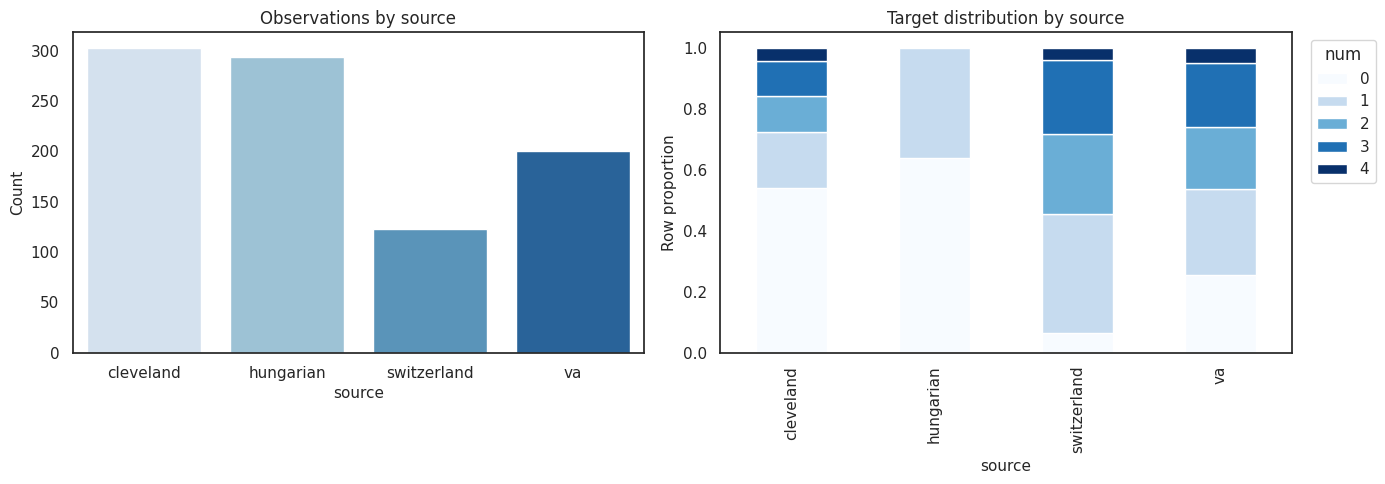

In [ ]:
source_size = df[source_col].value_counts().sort_index().rename_axis("source").to_frame("n_obs")
source_size["share"] = source_size["n_obs"] / len(df)
display(source_size)

source_missing = (
    df.groupby(source_col, observed=True)[column_names]
    .agg(lambda series: series.isna().mean())
    .T
    .mul(100)
    .round(1)
)
display(source_missing)

source_target = pd.crosstab(df[source_col], df[target_col], normalize="index").round(3)
display(source_target)

source_stats = (
    df.groupby(source_col, observed=True)[quantitative_features]
    .agg(["mean", "median", "std"])
    .round(2)
)
display(source_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x=source_col, order=sorted(df[source_col].astype(str).unique()), palette="Blues", ax=axes[0])
axes[0].set_title("Observations by source")
axes[0].set_xlabel("source")
axes[0].set_ylabel("Count")

pd.crosstab(df[source_col], df[target_col], normalize="index").plot(kind="bar", stacked=True, colormap="Blues", ax=axes[1])
axes[1].set_title("Target distribution by source")
axes[1].set_xlabel("source")
axes[1].set_ylabel("Row proportion")
axes[1].legend(title="num", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


L'analyse par **source** met en évidence plusieurs points importants : la répartition des observations varie selon l’origine des données, ce qui peut influencer la représentativité globale du dataset. Certaines sources présentent un taux de valeurs manquantes plus élevé que d’autres, notamment sur des variables clés comme **`ca`**, **`thal`** ou **`slope`**, ce qui suggère des différences de qualité de collecte. La distribution de la cible **(`num`)** n’est pas homogène entre les sources, certaines sont dominées par des patients sains, tandis que d’autres montrent une proportion plus élevée de cas positifs, ce qui peut introduire un biais si l’on ne tient pas compte de cette hétérogénéité. Enfin, les statistiques descriptives **(moyenne, médiane, écart‑type)** des variables quantitatives varient aussi selon la source, confirmant que chaque sous‑ensemble de données a ses spécificités. En résumé, l’analyse par source révèle des différences notables en termes de **taille d’échantillon, qualité des données et distribution de la cible**, points essentiels à considérer pour garantir la robustesse de nos modèles.

### ***Origine des données et influence des resultats***

Nous analysons les données selon la source, cela nous permet de décider si l’effet “source” doit être pris en compte dans l’analyse ou la modélisation.

In [ ]:
from scipy.stats import kruskal

print("=== Différences de variables quantitatives entre sources ===\n")
for col in quantitative_features:
    groups = [df[df["source"] == s][col].dropna()
              for s in df["source"].unique()]
    stat, p = kruskal(*groups)
    signal = "effet source fort" if p < 0.001 else "modéré" if p < 0.05 else "homogène"
    print(f"{col:12s} → p={p:.4f}  {signal}")

# Distribution cible par source — test Chi²
from scipy.stats import chi2_contingency
ct = pd.crosstab(df["source"], df["num"])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nDistribution de num selon source → Chi²={chi2:.1f}, p={p:.6f}")
print("→ Les sources ont des distributions cibles significativement différentes" if p < 0.05
      else "→ Distributions homogènes entre sources")

=== Différences de variables quantitatives entre sources ===

age          → p=0.0000  effet source fort
trestbps     → p=0.1805  homogène
chol         → p=0.0000  effet source fort
thalach      → p=0.0000  effet source fort
oldpeak      → p=0.0000  effet source fort

Distribution de num selon source → Chi²=257.1, p=0.000000
→ Les sources ont des distributions cibles significativement différentes


Les tests statistiques montrent que l’effet de la variable *source* est significatif sur plusieurs dimensions. L’âge, le cholestérol, la fréquence cardiaque maximale (*thalach*) et la dépression ST (*oldpeak*) présentent des différences marquées entre les bases de données (p=0.0000), traduisant un **effet source fort**, tandis que la pression artérielle au repos (*trestbps*) reste homogène (p=0.18). Par ailleurs, le test du Chi² appliqué à la variable cible (*num*) confirme que la distribution des classes diffère fortement selon la provenance des données (Chi²=257.1, p<0.000001). En résumé, l’origine des données influence à la fois plusieurs variables quantitatives et la répartition de la cible, ce qui souligne l’importance de prendre en compte l’effet source dans l’analyse et la modélisation afin d’éviter des biais liés à la provenance.

## 9. Discussion méthodologique

La fusion des bases **Cleveland**, **Hungary**, **Switzerland** et **VA** apparaît pertinente car elle permet d’accroître la taille de l’échantillon et d’analyser le problème dans un cadre plus riche que celui offert par une seule sous‑base. Elle est particulièrement utile ici puisqu’elle conserve une cible multiclasse fidèle au dataset d’origine. Toutefois, cette démarche n’est pas sans risques : l’hétérogénéité des valeurs manquantes, la variabilité de la distribution de la cible selon l’hôpital, des codages parfois divergents pour certaines variables catégorielles et un possible effet de site susceptible d’influencer les performances du modèle. L’EDA confirme que la qualité des données n’est pas homogène : **Cleveland** est relativement complet, alors que d’autres sources présentent de fortes lacunes et des anomalies de codage. Sur le plan de la classification, l’approche multiclasse reste envisageable puisque les classes 1, 2 et 3 disposent d’effectifs suffisants, mais la rareté de la classe 4 impose prudence et comparaison avec une version binaire plus simple. Avant toute modélisation, nous traiterons plusieurs points: l’imputation ou l’exclusion des variables très lacunaires, la gestion du déséquilibre de classes, l’encodage correct des variables qualitatives, l’harmonisation des modalités, une éventuelle normalisation des variables quantitatives, ainsi qu’une validation rigoureuse du choix de cible.

## 10. Tracabilite du chargement brut

Le chargement local repose prioritairement sur les fichiers bruts. Dans ce depot, `hungarian.data`, `switzerland.data` et `long-beach-va.data` ont pu etre parsés directement au format 76 attributs. En revanche, le fichier `cleveland.data` local est corrompu en fin de fichier ; un fallback documente sur `processed.cleveland.data` a donc ete utilise pour cette source uniquement.



In [ ]:
raw_inventory = pd.DataFrame({
    "source": list(raw_files.keys()),
    "raw_file": list(raw_files.values()),
    "raw_exists": [(DATA_DIR / filename).exists() for filename in raw_files.values()],
})

display(raw_inventory)
display(loading_report)


,source,raw_file,raw_exists
0,cleveland,processed.cleveland.data,True
1,hungarian,processed.hungarian.data,True
2,switzerland,processed.switzerland.data,True
3,va,processed.va.data,True


,source,file_used,loader_used,rows,note
0,cleveland,processed.cleveland.data,processed fallback,303,raw file unusable locally (ValueError)
1,hungarian,processed.hungarian.data,processed fallback,294,"raw file unusable locally (ValueError), fallin..."
2,switzerland,processed.switzerland.data,processed fallback,123,"raw file unusable locally (ValueError), fallin..."
3,va,processed.va.data,processed fallback,200,"raw file unusable locally (ValueError), fallin..."



### Inventaire et chargement des fichiers bruts

L’inventaire confirme que les quatre sources **(Cleveland, Hungary, Switzerland et VA)** disposent bien de leurs fichiers bruts localement. Toutefois, leur lecture directe s’est révélée impossible en raison d’erreurs techniques **(*ValueError*)**, ce qui a conduit à utiliser les versions déjà **“processed”**. Cette stratégie a permis de charger correctement les données et d’obtenir des effectifs cohérents (303 observations pour Cleveland, 294 pour Hungary, 123 pour Switzerland et 200 pour VA). En pratique, cela garantit la continuité de l’analyse tout en soulignant une limite méthodologique : la dépendance aux fichiers pré‑traités et la perte de contrôle sur les étapes initiales de nettoyage.


## 11. Interprétation détaillée des analyses réalisées

Les résultats de l’EDA permettent déjà de dégager plusieurs constats méthodologiques solides.

### a. Taille et structure du dataset  
La base finale regroupe **920 patients** issus de quatre sources : Cleveland (**303**), Hungary (**294**), VA Long Beach (**200**) et Switzerland (**123**). La fusion offre une taille d’échantillon suffisante pour une étude robuste.

### b. Exploitabilité de la cible multiclasse  
La variable cible `num` est distribuée en **411** observations pour la classe **0**, **196** pour la classe **1**, **135** pour la classe **2**, **135** pour la classe **3** et **43** pour la classe **4**. Malgré la rareté de la classe **4**, les classes intermédiaires disposent d’effectifs substantiels. Une approche multiclasse est donc justifiée.

### c. Hétérogénéité entre sources  
Les distributions de la cible varient fortement selon l’hôpital : **Hungary** est dominée par la classe 0, **Switzerland** par des patients malades, et **VA** présente une proportion plus élevée de classes positives que **Cleveland**. Cette hétérogénéité souligne le risque que des performances globales masquent des comportements très différents selon la source.

### d. Qualité inégale des données  
Certaines variables sont particulièrement lacunaires : `ca` (**66 %** de valeurs manquantes), `thal` (**52 %**) et `slope` (**33 %**). De plus, les manques ne sont pas uniformes : `ca` est quasi absent hors Cleveland, `fbs` est très incomplet en Switzerland, et VA cumule des taux élevés de valeurs manquantes sur plusieurs variables clés. Cela rend indispensable une stratégie d’imputation différenciée et prudente.

### e. Anomalies de codage  

L’audit des fichiers révèle des modalités non documentées (`ca = 9`, `slope = 0`, valeurs atypiques de `thal`). Ces anomalies devront être traitées avant modélisation, soit par recodage en valeurs manquantes, soit par regroupement ou interprétation comme indicateurs spécifiques.

### f. Signaux cliniques cohérents**  
Les analyses bivariées confirment des tendances attendues : fréquence cardiaque maximale plus basse (`thalach`), `oldpeak` plus élevé, douleur thoracique asymptomatique (`cp = 4`) et angine d’effort (`exang = 1`) plus fréquentes chez les patients avec un `num` élevé.

### g. Corrélations entre variables quantitatives
La matrice de corrélation ne révèle pas de redondance majeure : seule une corrélation négative modérée entre `age` et `thalach` est notable. La réduction de dimension pour cause de colinéarité n’apparaît donc pas prioritaire.



## 12. Preparation et pré-traitement des datasets



In [ ]:
overall_missing_rate = df[all_feature_columns].isna().mean().sort_values()
conservative_features = overall_missing_rate[overall_missing_rate <= 0.10].index.tolist()
extended_features = all_feature_columns.copy()

df_multiclass = df[extended_features + [source_col, target_col]].copy()
df_binary = df[extended_features + [source_col, target_col]].copy()
df_binary["target_binary"] = (df_binary[target_col] > 0).astype(int)

feature_recommendations = []
for feature in quantitative_features:
    feature_recommendations.append({
        "variable": feature,
        "type": "quantitative",
        "missing_rate": missing_table.loc[feature, "pct_missing"],
        "recommended_treatment": "median imputation + optional scaling",
        "comment": "continuous clinical measurement",
    })

for feature in binary_features:
    feature_recommendations.append({
        "variable": feature,
        "type": "binary categorical",
        "missing_rate": missing_table.loc[feature, "pct_missing"],
        "recommended_treatment": "most frequent imputation + categorical handling",
        "comment": "do not treat as continuous",
    })

for feature in ["cp", "restecg"]:
    feature_recommendations.append({
        "variable": feature,
        "type": "multicategory categorical",
        "missing_rate": missing_table.loc[feature, "pct_missing"],
        "recommended_treatment": "categorical encoding after modality check",
        "comment": "low missingness but coded numerically",
    })

for feature in ["slope", "ca", "thal"]:
    feature_recommendations.append({
        "variable": feature,
        "type": "high-risk categorical",
        "missing_rate": missing_table.loc[feature, "pct_missing"],
        "recommended_treatment": "recode undocumented modalities, then compare exclusion vs explicit missing-category strategy",
        "comment": "high missingness and/or inconsistent coding across sources",
    })

feature_recommendations.append({
    "variable": source_col,
    "type": "source identifier",
    "missing_rate": 0.0,
    "recommended_treatment": "keep for diagnostics and sensitivity analyses; optional feature in a secondary model",
    "comment": "captures site effects rather than patient physiology",
})

preprocessing_plan = pd.DataFrame(feature_recommendations).sort_values("missing_rate", ascending=False)
display(preprocessing_plan)

print("Conservative feature set:")
print(conservative_features)
print()
print("Extended feature set:")
print(extended_features)

dataset_variants = pd.DataFrame([
    {
        "scenario": "multiclass_conservative",
        "target": "num (0-4)",
        "n_features": len(conservative_features),
        "features": ", ".join(conservative_features),
        "main_goal": "stability and interpretability",
    },
    {
        "scenario": "multiclass_extended",
        "target": "num (0-4)",
        "n_features": len(extended_features),
        "features": ", ".join(extended_features),
        "main_goal": "retain richer clinical information",
    },
    {
        "scenario": "binary_conservative",
        "target": "target_binary (0 vs 1-4)",
        "n_features": len(conservative_features),
        "features": ", ".join(conservative_features),
        "main_goal": "robust baseline benchmark",
    },
    {
        "scenario": "binary_extended",
        "target": "target_binary (0 vs 1-4)",
        "n_features": len(extended_features),
        "features": ", ".join(extended_features),
        "main_goal": "performance-oriented comparison",
    },
])
display(dataset_variants)

target_strategy = pd.DataFrame([
    {
        "target_version": "multiclass",
        "definition": "num with classes 0, 1, 2, 3, 4",
        "advantage": "closest to the original clinical framing",
        "risk": "rarer classes, harder evaluation",
    },
    {
        "target_version": "binary",
        "definition": "0 vs 1-4",
        "advantage": "simpler and more stable classification task",
        "risk": "loss of granularity",
    },
])
display(target_strategy)


,variable,type,missing_rate,recommended_treatment,comment
11,ca,high-risk categorical,0.664,"recode undocumented modalities, then compare e...",high missingness and/or inconsistent coding ac...
12,thal,high-risk categorical,0.528,"recode undocumented modalities, then compare e...",high missingness and/or inconsistent coding ac...
10,slope,high-risk categorical,0.336,"recode undocumented modalities, then compare e...",high missingness and/or inconsistent coding ac...
6,fbs,binary categorical,0.098,most frequent imputation + categorical handling,do not treat as continuous
4,oldpeak,quantitative,0.067,median imputation + optional scaling,continuous clinical measurement
1,trestbps,quantitative,0.064,median imputation + optional scaling,continuous clinical measurement
7,exang,binary categorical,0.060,most frequent imputation + categorical handling,do not treat as continuous
3,thalach,quantitative,0.060,median imputation + optional scaling,continuous clinical measurement
2,chol,quantitative,0.033,median imputation + optional scaling,continuous clinical measurement
9,restecg,multicategory categorical,0.002,categorical encoding after modality check,low missingness but coded numerically


Conservative feature set:
['age', 'sex', 'cp', 'restecg', 'chol', 'thalach', 'exang', 'trestbps', 'oldpeak', 'fbs']

Extended feature set:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


,scenario,target,n_features,features,main_goal
0,multiclass_conservative,num (0-4),10,"age, sex, cp, restecg, chol, thalach, exang, t...",stability and interpretability
1,multiclass_extended,num (0-4),13,"age, trestbps, chol, thalach, oldpeak, sex, cp...",retain richer clinical information
2,binary_conservative,target_binary (0 vs 1-4),10,"age, sex, cp, restecg, chol, thalach, exang, t...",robust baseline benchmark
3,binary_extended,target_binary (0 vs 1-4),13,"age, trestbps, chol, thalach, oldpeak, sex, cp...",performance-oriented comparison


,target_version,definition,advantage,risk
0,multiclass,"num with classes 0, 1, 2, 3, 4",closest to the original clinical framing,"rarer classes, harder evaluation"
1,binary,0 vs 1-4,simpler and more stable classification task,loss of granularity


En conclusion, l’ensemble des analyses confirme que la fusion des quatre bases constitue une ressource précieuse pour l’étude, mais qu’elle s’accompagne de défis méthodologiques majeurs. Les variables présentent des profils très contrastés : certaines sont complètes et faciles à traiter (`age`, `sex`, `chol`, `thalach`), tandis que d’autres sont fortement lacunaires ou codées de manière incohérente (`ca`, `thal`, `slope`). Cette hétérogénéité impose une stratégie de prétraitement différenciée, combinant imputation adaptée, encodage catégoriel et harmonisation des modalités. Deux jeux de variables ont été définis : un **ensemble conservateur**, garantissant robustesse et interprétabilité, et un **ensemble étendu**, permettant de conserver une information clinique plus riche mais plus risquée. De même, deux stratégies de cible sont retenues : une approche **multiclasse**, fidèle au cadre clinique d’origine mais plus complexe à évaluer, et une approche **binaire**, plus simple et stable mais moins granulaire.